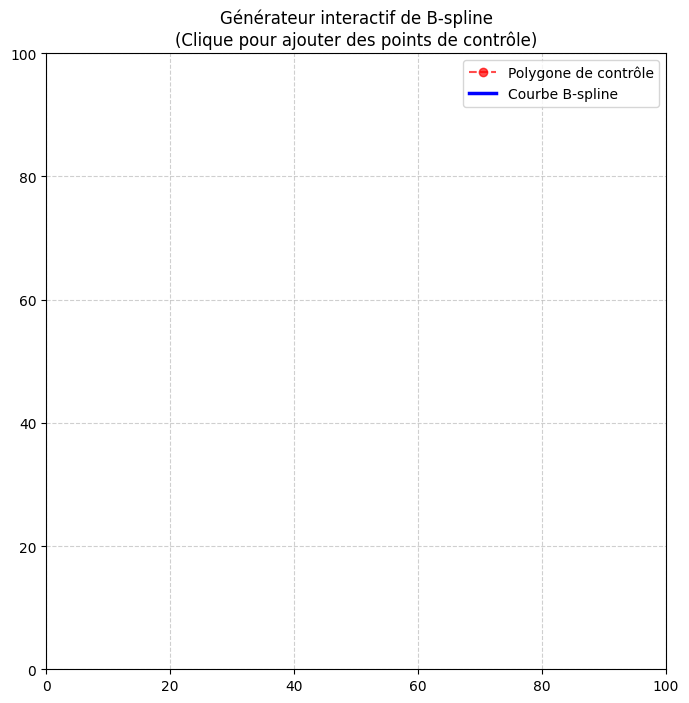

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Initialisation de la figure interactive
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Générateur interactif de B-spline\n(Clique pour ajouter des points de contrôle)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, linestyle='--', alpha=0.6)

points = []
# Initialisation des lignes vides pour le polygone et la courbe
line_points, = ax.plot([], [], 'ro--', label='Polygone de contrôle', alpha=0.7)
line_spline, = ax.plot([], [], 'b-', linewidth=2.5, label='Courbe B-spline')
ax.legend()

def onclick(event):
    # Ignorer les clics en dehors de la zone de tracé
    if event.xdata is None or event.ydata is None: 
        return
        
    # Ajouter le nouveau point cliqué
    points.append([event.xdata, event.ydata])
    pts = np.array(points)
    
    # Mettre à jour le tracé du polygone de contrôle
    line_points.set_data(pts[:, 0], pts[:, 1])
    
    # Une B-spline de degré 3 (cubique) a besoin d'au moins 4 points
    if len(pts) >= 4:
        # Paramétrisation t
        t = np.linspace(0, 1, len(pts))
        t_spline = np.linspace(0, 1, 300)
        
        # Génération de la B-spline cubique (k=3)
        spl = make_interp_spline(t, pts, k=3)
        pts_spline = spl(t_spline)
        
        # Mettre à jour le tracé de la B-spline
        line_spline.set_data(pts_spline[:, 0], pts_spline[:, 1])
        
    # Rafraîchir l'affichage
    fig.canvas.draw()

# Connecter l'événement de clic de souris à notre fonction
cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()